# Generate S-Matrix: Single Layer of PEC Cylinders

This notebook computes the **S-matrix** for a single slab of perfectly electrically
conducting (PEC) cylinders ($\varepsilon = -1$).

**What this example demonstrates:**
1. PEC cylinders use $\varepsilon = -1$ (convention for perfect conductors)
2. No evanescent modes are needed for PEC — only propagating modes
3. The S-matrix is **unitary** for PEC (lossless): $S^\dagger S = I$
4. Transmission eigenvalues and unitarity verification

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd, norm

sys.path.insert(0, '../..')

from Scattering_Code.smatrix_parameters import smatrix_parameters
from Scattering_Code.smatrix import smatrix
from Scattering_Code.ky import ky

## 1. Physical Parameters

PEC cylinders are specified by $\varepsilon = -1$. Since the wave cannot penetrate
a perfect conductor, there are no evanescent coupling effects, so we set $n_{eva} = 0$.

In [2]:
WAVELENGTH = 0.93
PERIOD     = 12.81
RADIUS     = 0.25
MU         = 1.0
CMMAX      = 5
PHIINC     = np.pi / 2
NUM_CYL    = 10
SEED       = 42

# PEC: no evanescent modes
n_prop = int(np.floor(PERIOD / WAVELENGTH))
n_eva  = 0
nmax   = n_prop
nm     = 2 * nmax + 1

print(f"n_prop = {n_prop}, n_eva = {n_eva}, nmax = {nmax}")
print(f"S-matrix size: {2*nm} x {2*nm}")

n_prop = 13, n_eva = 0, nmax = 13
S-matrix size: 54 x 54


## 2. Place Cylinders

In [3]:
spacing = 2.5 * RADIUS
cyls_per_row = int(PERIOD / spacing)
rows_needed = NUM_CYL / cyls_per_row + 2
thickness = round(max(0.5, rows_needed * spacing * 1.5), 1)

rng = np.random.RandomState(SEED)
margin = RADIUS * 1.5
min_sep = 2.5 * RADIUS
clocs = np.zeros((NUM_CYL, 2))

for i in range(NUM_CYL):
    for _ in range(10000):
        x = margin + rng.rand() * (PERIOD - 2*margin)
        y = margin + rng.rand() * (thickness - 2*margin)
        if i == 0 or np.all(np.sqrt((x - clocs[:i, 0])**2 + (y - clocs[:i, 1])**2) > min_sep):
            clocs[i] = [x, y]
            break

print(f"Thickness = {thickness}")

Thickness = 2.3


## 3. Visualize Geometry

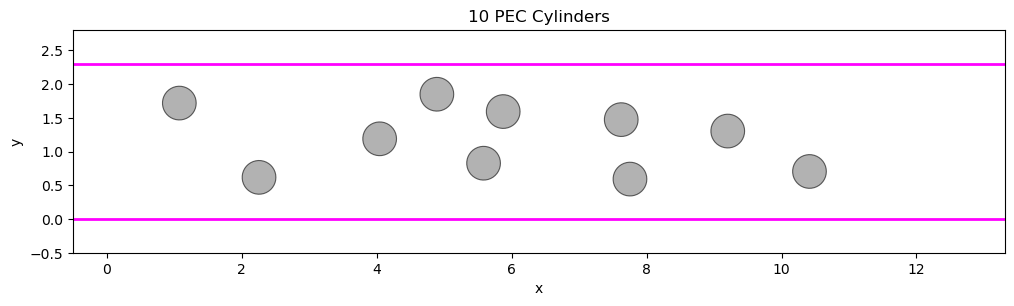

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
theta = np.linspace(0, 2*np.pi, 40)
for i in range(NUM_CYL):
    ax.fill(clocs[i,0] + RADIUS*np.cos(theta),
            clocs[i,1] + RADIUS*np.sin(theta),
            color='gray', alpha=0.6, edgecolor='black', lw=0.8)
ax.axhline(0, color='magenta', lw=2)
ax.axhline(thickness, color='magenta', lw=2)
ax.set_xlim(-0.5, PERIOD + 0.5)
ax.set_ylim(-0.5, thickness + 0.5)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'{NUM_CYL} PEC Cylinders')
plt.tight_layout()
plt.savefig('pec_geometry.png', dpi=150)
plt.show()

## 4. Compute S-Matrix

In [5]:
sp = smatrix_parameters(WAVELENGTH, PERIOD, PHIINC,
                        1e-11, 1e-4, 5, 3, 1000, 3, 5, 1, PERIOD/120)

cmmaxs = np.full(NUM_CYL, CMMAX, dtype=int)
cepmus = np.column_stack([np.full(NUM_CYL, -1.0), np.full(NUM_CYL, MU)])  # epsilon = -1 for PEC
crads  = np.full(NUM_CYL, RADIUS)

print("Computing S-matrix...")
S, _ = smatrix(clocs, cmmaxs, cepmus, crads, PERIOD, WAVELENGTH,
               nmax, thickness, sp, 'On')
print(f"S-matrix shape: {S.shape}")

Computing S-matrix...
  Computing T-Matrix...
  transall: 45 pairs (43 spectral, 2 spatial [vectorized])
  T-Matrix: 0.1s
  LU Decomposition...
  LU: 0.0s
  Computing S11 & S21...
  DEBUG: C_up.shape=(110, 27), nmax=13, GPU=False
  DEBUG: W2_up.shape=(27, 110)
  DEBUG: s21matrix.shape=(27, 27)
  S11&S21: 0.0s
  Computing S12 & S22...
  S12&S22: 0.0s
  Total: 0.1s (0.0 min)
S-matrix shape: (54, 54)


## 5. Unitarity Check

For PEC (lossless), the S-matrix must be unitary: $S_{11}^\dagger S_{11} + S_{21}^\dagger S_{21} = I$

In [6]:
S11 = S[:nm, :nm]
S21 = S[nm:, :nm]

unit_err = norm(S11.conj().T @ S11 + S21.conj().T @ S21 - np.eye(nm))
print(f"Unitarity error: ||S11'S11 + S21'S21 - I|| = {unit_err:.2e}")
print(f"{'PASS' if unit_err < 1e-3 else 'FAIL'}")

Unitarity error: ||S11'S11 + S21'S21 - I|| = 5.16e-11
PASS


## 6. Transmission Eigenvalues

max(tau^2) = 1.000000
sum(tau^2) = 16.4734


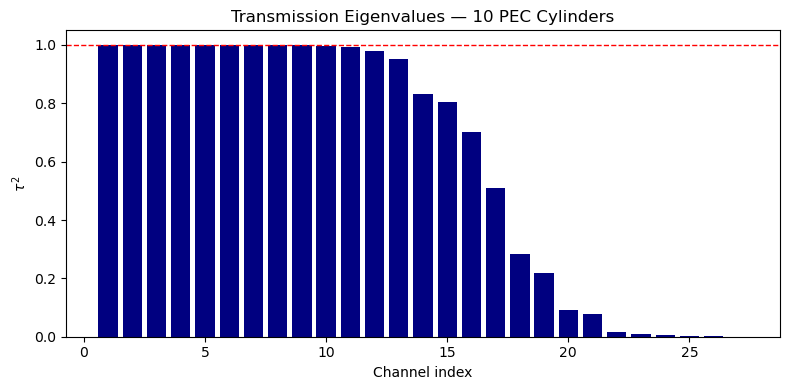

In [7]:
tau = svd(S21, compute_uv=False)

print(f"max(tau^2) = {np.max(tau**2):.6f}")
print(f"sum(tau^2) = {np.sum(tau**2):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(tau)+1), tau**2, color='navy')
ax.axhline(1.0, color='red', ls='--', lw=1)
ax.set_xlabel('Channel index')
ax.set_ylabel(r'$\tau^2$')
ax.set_title(f'Transmission Eigenvalues — {NUM_CYL} PEC Cylinders')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('pec_singular_values.png', dpi=150)
plt.show()